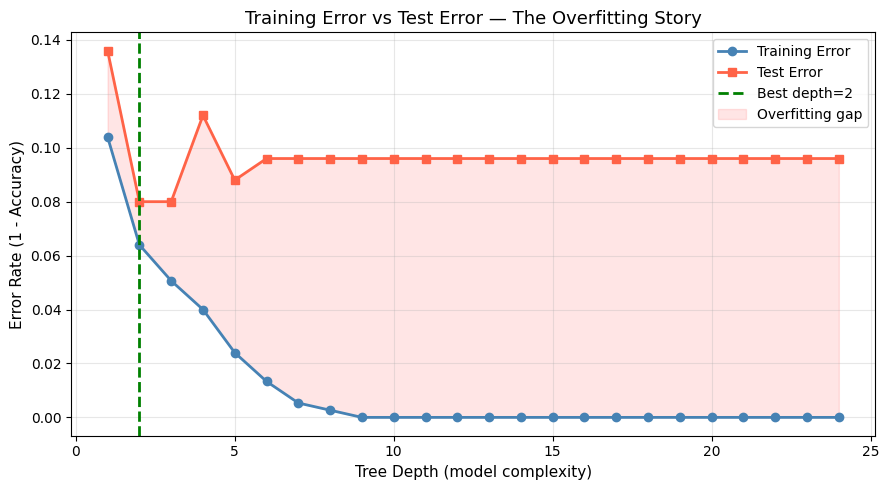

In [ ]:
# ■■ Training Error vs Test Error Gap ■■
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt, numpy as np
X, y = make_classification(n_samples=500, n_features=10, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42)
train_errs, test_errs = [], []
depths = range(1, 25)
for d in depths:
  tree = DecisionTreeClassifier(
      max_depth=d,
      random_state=42)
  tree.fit(X_train, y_train)
  train_errs.append(1 - accuracy_score(y_train, tree.predict(X_train)))
  test_errs.append(1 - accuracy_score(y_test, tree.predict(X_test)))
best = depths[test_errs.index(min(test_errs))]
plt.figure(figsize=(9, 5))
plt.plot(depths, train_errs, 'o-', lw=2, color='steelblue', label='Training Error')
plt.plot(depths, test_errs, 's-', lw=2, color='tomato', label='Test Error')
plt.axvline(x=best, color='green', lw=2, linestyle='--', label=f'Best depth={best}')
plt.fill_between(depths, train_errs, test_errs, alpha=0.1, color='red', label='Overfitting gap')
plt.xlabel('Tree Depth (model complexity)', fontsize=11)
plt.ylabel('Error Rate (1 - Accuracy)', fontsize=11)
plt.title('Training Error vs Test Error — The Overfitting Story', fontsize=13)
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

In [ ]:
# ■■ Cross-Validation: One-liner + StratifiedKFold + Pipeline ■■
from sklearn.datasets import make_classification
from sklearn.model_selection import (cross_val_score, KFold,
StratifiedKFold, cross_validate)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import numpy as np

X, y = make_classification(n_samples=600, n_features=10, random_state=42)
model = RandomForestClassifier(n_estimators=100, random_state=42)

# ■■ Method 1: Simplest one-liner ■■
scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
print(f'5-Fold CV Scores: {scores.round(3)}')
print(f'Mean: {scores.mean():.3f} Std: {scores.std():.3f}')
print(f'Reliable range: {scores.mean()-2*scores.std():.3f} – {scores.mean()+2*scores.std():.3f}')

# ■■ Method 2: StratifiedKFold (keeps class ratio in each fold) ■■
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
strat_scores = cross_val_score(model, X, y, cv=skf, scoring='f1_macro')
print(f'\nStratified 5-Fold F1: {strat_scores.mean():.3f} ± {strat_scores.std():.3f}')

# ■■ Method 3: cross_validate — get multiple metrics at once ■■
results = cross_validate(model, X, y, cv=5,
scoring=['accuracy','f1_macro','roc_auc'],
    return_train_score=True)
print('\ncross_validate results:')
for metric in ['accuracy','f1_macro','roc_auc']:
  train_k = f'train_{metric}'
  test_k = f'test_{metric}'
  print(f' {metric:12s}: train={results[train_k].mean():.3f} test={results[test_k].mean():.3f}')

  # ■■ Method 4: Pipeline + CV (scale inside CV — no data leakage!) ■■
pipe = Pipeline([
('scaler', StandardScaler()), # Scale inside each fold
('model', LogisticRegression(max_iter=1000))
])
pipe_scores = cross_val_score(pipe, X, y, cv=5, scoring='accuracy')
print(f'\nPipeline CV (no leakage): {pipe_scores.mean():.3f} ± {pipe_scores.std():.3f}')

5-Fold CV Scores: [0.858 0.933 0.908 0.9   0.942]
Mean: 0.908 Std: 0.029
Reliable range: 0.850 – 0.967

Stratified 5-Fold F1: 0.908 ± 0.027

cross_validate results:
 accuracy    : train=1.000 test=0.908
 f1_macro    : train=1.000 test=0.908
 roc_auc     : train=1.000 test=0.970

Pipeline CV (no leakage): 0.915 ± 0.030


In [ ]:
# ■■ Model Comparison Leaderboard ■■
from sklearn.datasets import make_classification
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import pandas as pd, numpy as np, matplotlib.pyplot as plt
X, y = make_classification(n_samples=800, n_features=15, random_state=42)
# ■■ Define models (wrapped in Pipeline to include scaling) ■■
models = {
'Logistic Regression' : Pipeline([('sc',StandardScaler()),('m',LogisticRegression(max_iter=1000))]),
'Decision Tree' : DecisionTreeClassifier(max_depth=5, random_state=42),
'Random Forest' : RandomForestClassifier(n_estimators=100, random_state=42),
'KNN (k=5)' : Pipeline([('sc',StandardScaler()),('m',KNeighborsClassifier(n_neighbors=5))])
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []
for name, model in models.items():
  cv_res = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=['accuracy', 'f1_macro', 'roc_auc'], return_train_score=False
    )
    results.append({
        'Model': name,
        'Accuracy': cv_res['test_accuracy'].mean(),
        'F1 Score': cv_res['test_f1_macro'].mean(),
        'AUC-ROC': cv_res['test_roc_auc'].mean(),
        'CV Std': cv_res['test_accuracy'].std(),
     })
    print(
        f'{name:22s}: '
        f'Acc={results[-1]["Accuracy"]:.3f} '
        f'F1={results[-1]["F1 Score"]:.3f} '
        f'AUC={results[-1]["AUC-ROC"]:.3f} '
     )
df_res = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
df_res[['Accuracy','F1 Score','AUC-ROC','CV Std']] = df_res[['Accuracy','F1 Score','AUC-ROC','CV Std']].round(4)
print('\n' + '='*70)
print('MODEL LEADERBOARD')
print('='*70)
print(df_res.to_string(index=False))

Logistic Regression   : Acc=0.930 F1=0.930 AUC=0.975 
Decision Tree         : Acc=0.925 F1=0.925 AUC=0.948 
Random Forest         : Acc=0.936 F1=0.936 AUC=0.977 
KNN (k=5)             : Acc=0.886 F1=0.886 AUC=0.949 

MODEL LEADERBOARD
              Model  Accuracy  F1 Score  AUC-ROC  CV Std
      Random Forest    0.9362    0.9362   0.9775  0.0310
Logistic Regression    0.9300    0.9300   0.9752  0.0222
      Decision Tree    0.9250    0.9249   0.9481  0.0265
          KNN (k=5)    0.8863    0.8860   0.9487  0.0242
